In [17]:
import numpy as np
import poisson_hypergraph
import xgi
import matplotlib.pyplot as plt
from matplotlib import colormaps as cm
import os

path = os.path.abspath("computermodernstyle.mplstyle")
plt.style.use(path)
def make_plot(NMIs_end, NMIs_best, grain, ticks_2D):
    step = int(grain/10)

    x_ticks = []
    y_ticks = []

    for i in range(len(ticks_2D)):
        vals = ticks_2D[i][0][:2]
        y_ticks.append(round(float(vals[0]) - float(vals[1]),2))
    
    for i in range(len(ticks_2D)):
        vals = ticks_2D[0][i][2:]
        x_ticks.append(round(float(vals[0]) - float(vals[1]),2))

    # y_ticks.reverse()
    x_ticks.reverse()

    figs,axs = plt.subplots(1,2)
    cmap = cm['hot']
    cmap.set_bad('black',1.)
    img1 = axs[1].imshow(NMIs_end, cmap=cmap, interpolation='nearest', origin = "lower", vmin=0, vmax=1)
    axs[1].set_xticks(list(range(0, grain - 1, step)))
    axs[1].set_yticks(list(range(0, grain - 1, step)))
    axs[1].set_xticklabels(x_ticks, rotation=90)
    axs[1].set_yticklabels(y_ticks)
    axs[1].set_xlabel("Lambda diff")
    axs[1].set_ylabel("ETA diff")
    axs[1].set_title("Final Labels NMI")

    cmap = cm['hot']
    cmap.set_bad('black',1.)
    img2 = axs[0].imshow(NMIs_best, cmap=cmap, interpolation='nearest', origin = "lower", vmin=0, vmax=1)
    axs[0].set_xticks(list(range(0, grain - 1, step)))
    axs[0].set_yticks(list(range(0, grain - 1, step)))
    axs[0].set_xticklabels(x_ticks, rotation=90)
    axs[0].set_yticklabels(y_ticks)
    axs[0].set_xlabel("Lambda diff")
    axs[0].set_ylabel("ETA diff")
    axs[0].set_title("Best LL Labels NMI")
    
    plt.tight_layout()
    

    figs.subplots_adjust(right=0.85)
    figs.suptitle("Stochastic E-Step Algo")
    cbar_ax = figs.add_axes([0.9, 0.15, 0.05, 0.7])
    figs.colorbar(img1, cax=cbar_ax)

    

    
    plt.show()

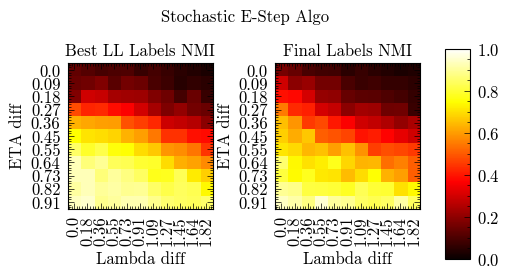

In [18]:
import csv
import math

GRID_SIZE = 11
def generate_LL_NMI_list(filename):
    LLs = [0] * GRID_SIZE*GRID_SIZE 
    NMIs = [0] * GRID_SIZE*GRID_SIZE
    params = [0] * GRID_SIZE*GRID_SIZE
    
    with open(filename, 'r', newline="") as f:
        reader = csv.reader(f)

        for row in reader:
            index = int(row[0])*-1
            
            NMIs[index] = row[1]
            LLs[index] = row[2]
            params[index] = [row[3],row[4],row[5], row[6]]

            
    params = params[1:] + params[:1]
    LLs = LLs[1:] + LLs[:1]
    NMIs = NMIs[1:] + NMIs[:1]
        
    return LLs, NMIs, params


# def parameter_list_init():
#     param_list = []
#     for a in range((GRID_SIZE)):
#         eta_plus = .5 + a/GRID_SIZE/2
#         eta_minus = .5 - a/GRID_SIZE/2
#         for b in range((GRID_SIZE)):
#             lambda_plus = 1 + b/GRID_SIZE
#             lambda_minus = 1 - b/GRID_SIZE

#             param_list.append([eta_plus, eta_minus, lambda_plus, lambda_minus])

#     return param_list

# params = parameter_list_init()


LLs, NMIs, params = generate_LL_NMI_list('modularity_maximization_NMI.csv')

params_2D = []
len_sqrt = int(math.sqrt(len(params)))
for i in range(len_sqrt):
    temp = []
    for j in range(len_sqrt):
        temp.append(params[i*len_sqrt + j])
    params_2D.append(temp)

NMIs_2D = []

len_sqrt = int(math.sqrt(len(NMIs)))
for i in range(len_sqrt):
    temp = []
    for j in range(len_sqrt):
        temp.append(NMIs[i*len_sqrt + j])
    NMIs_2D.append(temp)

NMIs_end_2D = np.array(NMIs_2D, dtype=float)


LLs, NMIs, params = generate_LL_NMI_list('paramter_sweep_flip_best_LL.csv')

params_2D = []
len_sqrt = int(math.sqrt(len(params)))
for i in range(len_sqrt):
    temp = []
    for j in range(len_sqrt):
        temp.append(params[i*len_sqrt + j])
    params_2D.append(temp)

NMIs_2D = []

len_sqrt = int(math.sqrt(len(NMIs)))
for i in range(len_sqrt):
    temp = []
    for j in range(len_sqrt):
        temp.append(NMIs[i*len_sqrt + j])
    NMIs_2D.append(temp)

NMIs_best_2D = np.array(NMIs_2D, dtype=float)


make_plot(NMIs_end_2D, NMIs_best_2D, 12, params_2D)



